Dataset Overview:
       Mean_IP     Std_IP  Excess_Kurt_IP  Skewness_IP   Mean_DM     Std_DM  \
0  102.507812  58.882430        0.465318    -0.515088  1.677258  14.860146   
1  103.015625  39.341649        0.323328     1.051164  3.121237  21.744669   
2  136.750000  57.178449       -0.068415    -0.636238  3.642977  20.959280   
3   88.726562  40.672225        0.600866     1.123492  1.178930  11.468720   
4   93.570312  46.698114        0.531905     0.416721  1.636288  14.545074   

   Excess_Kurt_DM  Skewness_DM  Class  
0       10.576487   127.393580      0  
1        7.735822    63.171909      0  
2        6.896499    53.593661      0  
3       14.269573   252.567306      0  
4       10.621748   131.394004      0  

Dataset Summary:
             Mean_IP        Std_IP  Excess_Kurt_IP   Skewness_IP       Mean_DM  \
count  17897.000000  17897.000000    17897.000000  17897.000000  17897.000000   
mean     111.078321     46.549021        0.477897      1.770417     12.614926   
std       

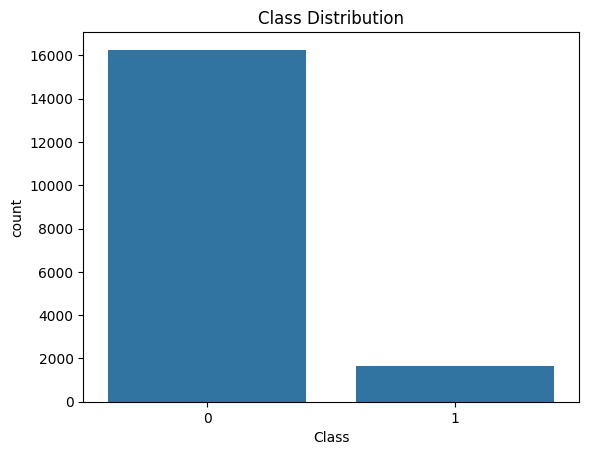


Model Accuracy: 0.9508379888268157

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      3259
           1       0.68      0.86      0.76       321

    accuracy                           0.95      3580
   macro avg       0.83      0.91      0.87      3580
weighted avg       0.96      0.95      0.95      3580



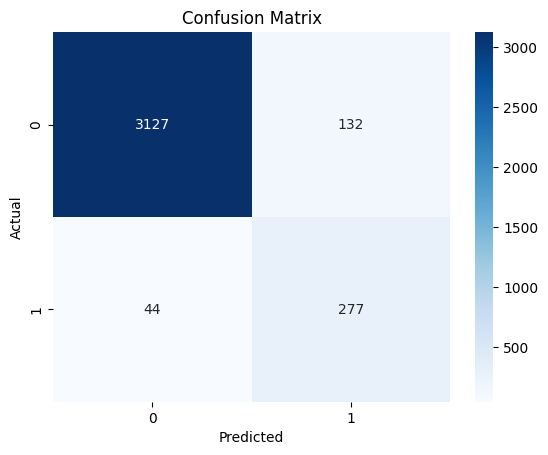


Model Accuracy with Prior Probabilities: 0.9463687150837988


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
file_path = "HTRU_2.csv"
df = pd.read_csv(file_path)

# Renaming columns for clarity
df.columns = ["Mean_IP", "Std_IP", "Excess_Kurt_IP", "Skewness_IP", 
              "Mean_DM", "Std_DM", "Excess_Kurt_DM", "Skewness_DM", "Class"]

# Display basic dataset information
print("Dataset Overview:\n", df.head())
print("\nDataset Summary:\n", df.describe())
print("\nClass Distribution:\n", df['Class'].value_counts())

# Visualizing class distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

# Splitting data into train and test sets
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the GaussianNB model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred = gnb.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Additional Insights
# Checking the effect of prior probabilities
gnb_with_prior = GaussianNB(priors=[0.8, 0.2])
gnb_with_prior.fit(X_train, y_train)
y_pred_prior = gnb_with_prior.predict(X_test)
accuracy_prior = accuracy_score(y_test, y_pred_prior)
print("\nModel Accuracy with Prior Probabilities:", accuracy_prior)
